
## AVA Training System — Laboratoires Vital

**Business Objective:** Improve the learning quality of medical representatives before real field visits.  
**Data Science Objective:** Analyze and score spoken medical interactions using NLP to provide feedback.

---
**Datasets:**
- `ava_training_dataset_vital_COMPLET.json` — AVA Q&A training dataset (170 entries)
- `parapharmacie_vital_dynamic.json` — Parapharmacie product catalog (265 entries)

---

# 📑 Table of Contents
---

## 📣 BO4 — Audience Segmentation for Targeted Marketing
> *Build an unsupervised segmentation system with LLMs (text) and diffusion models (images)*

| # | Section |
|---|---|
| **Dataset — vital_with_reviews.json** | |
| BO4.1 | Load Dataset |
| BO4.2 | Overview & Schema |
| BO4.3 | Missing Values & Data Quality |
| BO4.4 | Review Volume Distribution |
| BO4.5 | Rating Analysis |
| BO4.6 | Review Text Analysis & Sentiment Proxy |
| BO4.7 | Top Keywords by Sentiment (Audience Signals) |
| BO4.8 | Reviewer Profiles (Segmentation Signals) |
| BO4.9 | Product Segmentation by Gamme |
| BO4.10 | NLP Readiness Assessment |
| BO4.11 | BO4 Data Quality Summary |

---


---
---
# 📣 BO4 — Data Acquisition & Understanding
## Audience Segmentation for Compliant Targeted Marketing

**Business Objective:** Increase product visibility with compliant, targeted marketing content.  
**Data Science Objective:** Build an unsupervised audience segmentation system with LLMs (text) and diffusion models (images) for compliant targeted content.

**Dataset:** `vital_with_reviews.json` — 264 products with customer reviews (267 reviews total)

---

## 📂 BO4.1 — Load Dataset

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

TEAL = '#009688'
GREEN = '#4CAF50'
DARK_GREEN = '#1B5E20'

# ⚠️ Update path if needed
REVIEWS_PATH = 'vital_with_reviews.json'

with open(REVIEWS_PATH, encoding='utf-8') as f:
    reviews_raw = json.load(f)

df_products = pd.DataFrame([
    {
        'url': p['url'],
        'name': p['name'],
        'prix_raw': p.get('prix', ''),
        'note_moyenne_raw': p.get('note_moyenne', ''),
        'nb_avis': p.get('nb_avis', 0),
        'nb_avis_actual': len(p.get('avis', [])),
        'avis': p.get('avis', [])
    }
    for p in reviews_raw
])

# Parse numeric fields
df_products['prix'] = pd.to_numeric(
    df_products['prix_raw'].astype(str).str.extract(r'([\d.]+)')[0], errors='coerce')
df_products['note_moyenne'] = pd.to_numeric(
    df_products['note_moyenne_raw'].astype(str).str.extract(r'([\d.]+)')[0], errors='coerce')

# Flatten all reviews into a separate dataframe
all_reviews = []
for p in reviews_raw:
    for r in p.get('avis', []):
        note_val = pd.to_numeric(
            re.search(r'(\d+)', str(r.get('note', ''))).group(1)
            if re.search(r'(\d+)', str(r.get('note', ''))) else None, errors='coerce')
        all_reviews.append({
            'product': p['name'],
            'auteur': r.get('auteur', ''),
            'note': note_val,
            'commentaire': r.get('commentaire', ''),
            'len_comment': len(str(r.get('commentaire', ''))),
            'has_text': len(str(r.get('commentaire', ''))) > 5
        })

df_reviews = pd.DataFrame(all_reviews)

print(f'✅ Products     : {len(df_products)}')
print(f'✅ Total reviews: {len(df_reviews)}')
print(f'✅ With text    : {df_reviews["has_text"].sum()} ({df_reviews["has_text"].mean()*100:.1f}%)')
print(f'✅ Products with at least 1 review: {(df_products["nb_avis_actual"] > 0).sum()}')

✅ Products     : 264
✅ Total reviews: 267
✅ With text    : 156 (58.4%)
✅ Products with at least 1 review: 76


## 📊 BO4.2 — Overview & Schema

In [ ]:
print('=== Products Dataset — First 5 rows ===')
df_products[['name', 'prix', 'note_moyenne', 'nb_avis', 'nb_avis_actual']].head()

=== Products Dataset — First 5 rows ===


,name,prix,note_moyenne,nb_avis,nb_avis_actual
0,Vital Oligovit Zinc Bt/15 Gelules,6.269,4.40,5,5
1,Omevie Omega 3 – 1000 30 Capsules,31.345,4.64,11,11
2,Vital Oligovit Vitamine C Bt/30,5.821,4.58,24,24
3,Pédiakids Creme Pour Le Change 40 Gr,10.402,4.31,16,16
4,Phytothera Coenzyme Q10 – 30 Gélules,35.822,4.40,5,5


In [ ]:
print('=== Reviews Dataset — First 5 rows ===')
df_reviews.head()

=== Reviews Dataset — First 5 rows ===


,product,auteur,note,commentaire,len_comment,has_text
0,Vital Oligovit Zinc Bt/15 Gelules,Ahmad KHALDI,5,😀,1,False
1,Vital Oligovit Zinc Bt/15 Gelules,Hous,5,Excellent,9,True
2,Vital Oligovit Zinc Bt/15 Gelules,I N E S,5,good,4,False
3,Vital Oligovit Zinc Bt/15 Gelules,Imen Mahjoubi,4,nice product,12,True
4,Vital Oligovit Zinc Bt/15 Gelules,sywar bouaziz,3,Je n’ai pas aimé ces comprimés. Ils contiennen...,239,True


## 🔍 BO4.3 — Missing Values & Data Quality

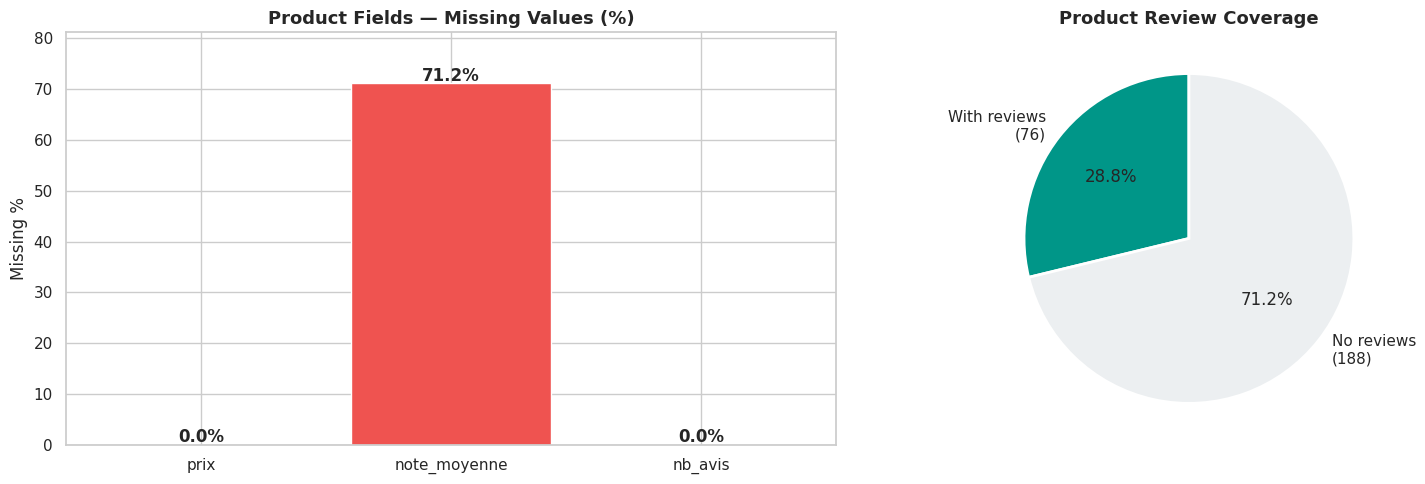

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Products missing values
missing_prod = df_products[['prix', 'note_moyenne', 'nb_avis']].isnull().sum()
missing_prod_pct = (missing_prod / len(df_products) * 100).round(1)
colors_m = ['#EF5350' if v > 30 else '#FFA726' if v > 10 else TEAL for v in missing_prod_pct.values]
axes[0].bar(missing_prod_pct.index, missing_prod_pct.values, color=colors_m)
axes[0].set_title('Product Fields — Missing Values (%)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Missing %')
for i, v in enumerate(missing_prod_pct.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].set_ylim(0, max(missing_prod_pct.max() + 10, 20))

# Reviews coverage
with_reviews = (df_products['nb_avis_actual'] > 0).sum()
without_reviews = len(df_products) - with_reviews
axes[1].pie([with_reviews, without_reviews],
            labels=[f'With reviews\n({with_reviews})', f'No reviews\n({without_reviews})'],
            autopct='%1.1f%%',
            colors=[TEAL, '#ECEFF1'],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Product Review Coverage', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 📈 BO4.4 — Review Volume Distribution

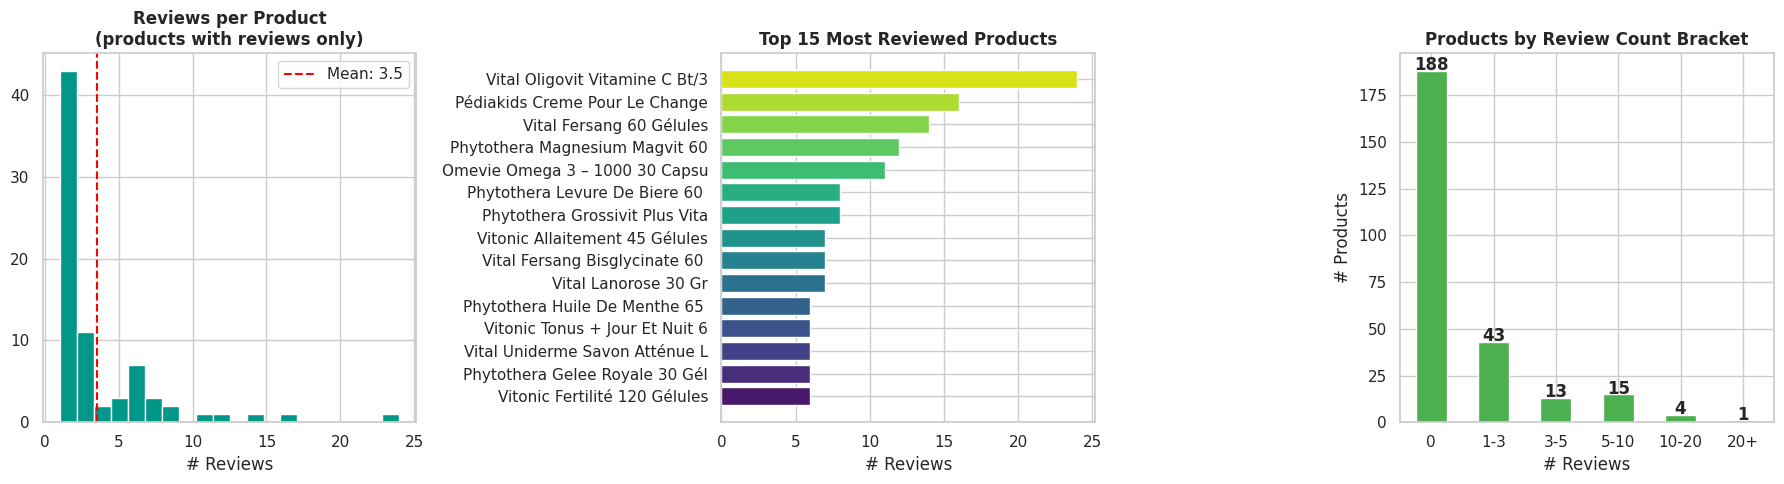

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Review count per product (only those with reviews)
with_rev = df_products[df_products['nb_avis_actual'] > 0]['nb_avis_actual']
axes[0].hist(with_rev, bins=20, color=TEAL, edgecolor='white')
axes[0].axvline(with_rev.mean(), color='red', linestyle='--', label=f'Mean: {with_rev.mean():.1f}')
axes[0].set_title('Reviews per Product\n(products with reviews only)', fontweight='bold')
axes[0].set_xlabel('# Reviews')
axes[0].legend()

# Top 15 most reviewed products
top_reviewed = df_products.nlargest(15, 'nb_avis_actual')[['name', 'nb_avis_actual']]
top_reviewed['name_short'] = top_reviewed['name'].str[:30]
axes[1].barh(list(reversed(top_reviewed['name_short'].tolist())),
             list(reversed(top_reviewed['nb_avis_actual'].tolist())),
             color=sns.color_palette('viridis', 15))
axes[1].set_title('Top 15 Most Reviewed Products', fontweight='bold')
axes[1].set_xlabel('# Reviews')

# Review brackets
bins_r = [0, 1, 3, 5, 10, 20, 9999]
labels_r = ['0', '1-3', '3-5', '5-10', '10-20', '20+']
df_products['review_bracket'] = pd.cut(df_products['nb_avis_actual'], bins=bins_r, labels=labels_r, right=False)
bracket_r = df_products['review_bracket'].value_counts().sort_index()
bracket_r.plot(kind='bar', ax=axes[2], color=GREEN, edgecolor='white')
axes[2].set_title('Products by Review Count Bracket', fontweight='bold')
axes[2].set_xlabel('# Reviews')
axes[2].set_ylabel('# Products')
axes[2].tick_params(axis='x', rotation=0)
for bar in axes[2].patches:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(int(bar.get_height())), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

👉 The analysis shows that most products have no customer reviews, while only a few concentrate user engagement, indicating an opportunity to enrich real-world field data.

## ⭐ BO4.5 — Rating Analysis (Product & Review Level)

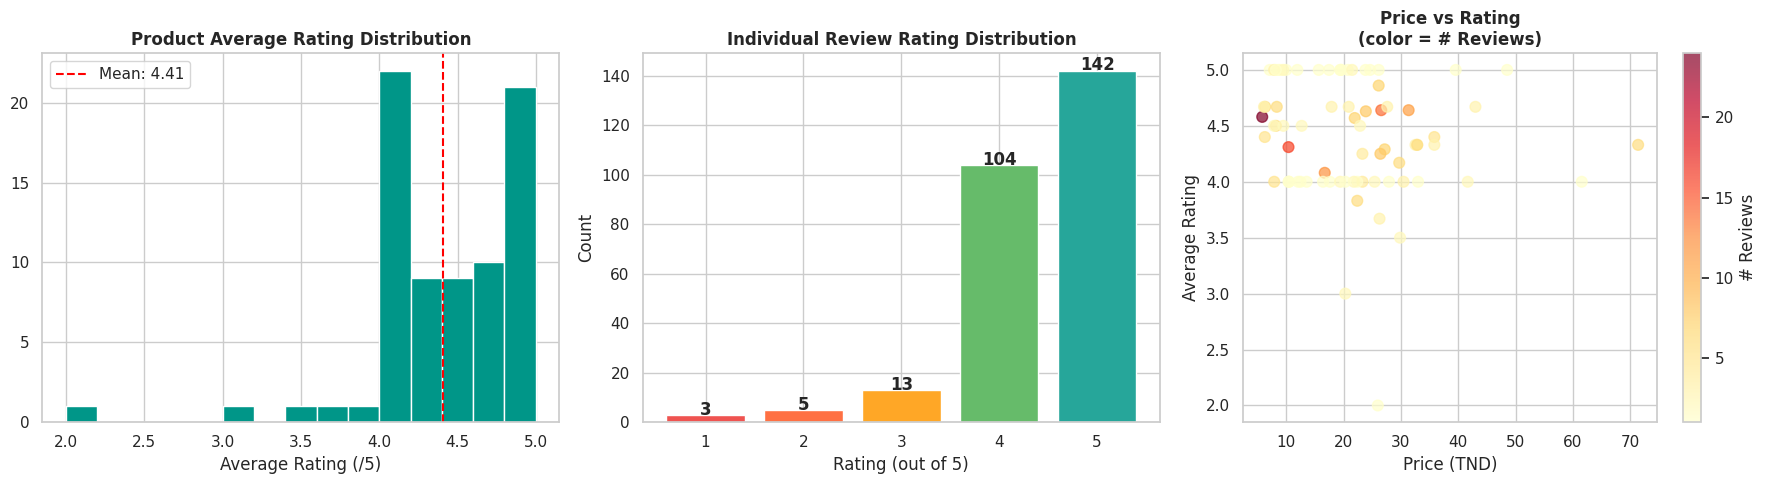


⭐ Rating breakdown:
  1 ⭐:                        3 (1.1%)
  2 ⭐:                        5 (1.9%)
  3 ⭐: █                     13 (4.9%)
  4 ⭐: ████████████         104 (39.0%)
  5 ⭐: █████████████████    142 (53.2%)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Product average ratings
note_clean = df_products['note_moyenne'].dropna()
axes[0].hist(note_clean, bins=15, color=TEAL, edgecolor='white')
axes[0].axvline(note_clean.mean(), color='red', linestyle='--', label=f'Mean: {note_clean.mean():.2f}')
axes[0].set_title('Product Average Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Average Rating (/5)')
axes[0].legend()

# Individual review ratings
review_notes = df_reviews['note'].dropna()
note_counts = review_notes.value_counts().sort_index()
colors_n = ['#EF5350', '#FF7043', '#FFA726', '#66BB6A', '#26A69A']
bars = axes[1].bar(note_counts.index, note_counts.values, color=colors_n[:len(note_counts)])
axes[1].set_title('Individual Review Rating Distribution', fontweight='bold')
axes[1].set_xlabel('Rating (out of 5)')
axes[1].set_ylabel('Count')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(int(bar.get_height())), ha='center', fontweight='bold')

# Price vs Rating scatter
df_scatter = df_products.dropna(subset=['prix', 'note_moyenne'])
sc = axes[2].scatter(df_scatter['prix'], df_scatter['note_moyenne'],
                     c=df_scatter['nb_avis_actual'], cmap='YlOrRd', s=60, alpha=0.7)
plt.colorbar(sc, ax=axes[2], label='# Reviews')
axes[2].set_title('Price vs Rating\n(color = # Reviews)', fontweight='bold')
axes[2].set_xlabel('Price (TND)')
axes[2].set_ylabel('Average Rating')

plt.tight_layout()
plt.show()

print(f'\n⭐ Rating breakdown:')
for note, cnt in note_counts.items():
    pct = cnt / len(review_notes) * 100
    bar_vis = '█' * int(pct / 3)
    print(f'  {int(note)} ⭐: {bar_vis:20s} {cnt:3d} ({pct:.1f}%)')

👉 Most products receive high ratings (around 4–5★), showing strong customer satisfaction.
Negative reviews are rare, and price does not significantly influence ratings.
Products with more reviews tend to maintain high scores, reinforcing trust.

## 💬 BO4.6 — Review Text Analysis & Sentiment Proxy

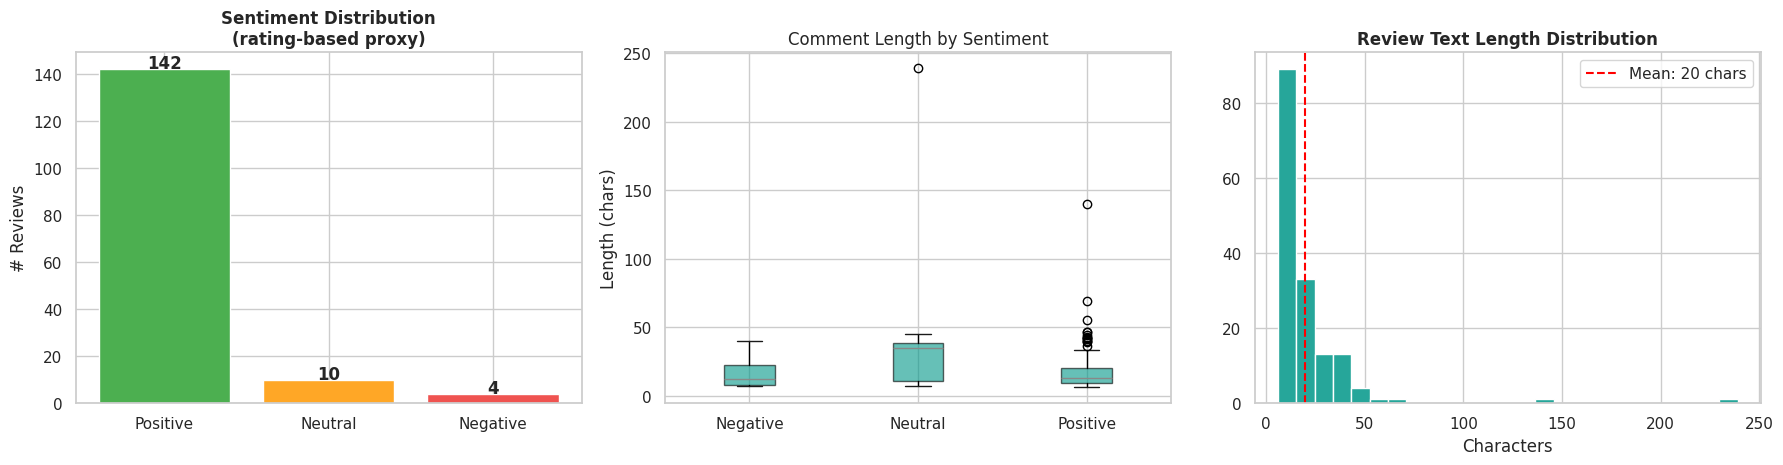


💬 Review Text Stats:
  Total reviews with text : 156
  Positive                : 142
  Neutral                 : 10
  Negative                : 4
  Avg comment length      : 20 chars


In [ ]:
df_text = df_reviews[df_reviews['has_text']].copy()

# Sentiment proxy based on rating
def sentiment_label(note):
    if note >= 4:
        return 'Positive'
    elif note == 3:
        return 'Neutral'
    else:
        return 'Negative'

df_text['sentiment'] = df_text['note'].apply(sentiment_label)
df_reviews['sentiment'] = df_reviews['note'].apply(sentiment_label)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sentiment distribution
sentiment_counts = df_text['sentiment'].value_counts()
colors_s = {'Positive': '#4CAF50', 'Neutral': '#FFA726', 'Negative': '#EF5350'}
bar_colors = [colors_s[s] for s in sentiment_counts.index]
bars = axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=bar_colors)
axes[0].set_title('Sentiment Distribution\n(rating-based proxy)', fontweight='bold')
axes[0].set_ylabel('# Reviews')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(int(bar.get_height())), ha='center', fontweight='bold')

# Comment length by sentiment
df_text.boxplot(column='len_comment', by='sentiment', ax=axes[1],
                patch_artist=True,
                boxprops=dict(facecolor=TEAL, alpha=0.6))
axes[1].set_title('Comment Length by Sentiment', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Length (chars)')
plt.sca(axes[1])
plt.title('Comment Length by Sentiment')

# Length distribution of comments
axes[2].hist(df_text['len_comment'], bins=25, color='#26A69A', edgecolor='white')
axes[2].axvline(df_text['len_comment'].mean(), color='red', linestyle='--',
                label=f"Mean: {df_text['len_comment'].mean():.0f} chars")
axes[2].set_title('Review Text Length Distribution', fontweight='bold')
axes[2].set_xlabel('Characters')
axes[2].legend()

plt.suptitle('')
plt.tight_layout()
plt.show()

print(f'\n💬 Review Text Stats:')
print(f'  Total reviews with text : {len(df_text)}')
print(f'  Positive                : {(df_text["sentiment"]=="Positive").sum()}')
print(f'  Neutral                 : {(df_text["sentiment"]=="Neutral").sum()}')
print(f'  Negative                : {(df_text["sentiment"]=="Negative").sum()}')
print(f'  Avg comment length      : {df_text["len_comment"].mean():.0f} chars')

👉 Most reviews are positive, with very few negative comments.
Customer comments are generally very short (≈20 characters).
Neutral reviews tend to be slightly longer than positive or negative ones.

## 🔑 BO4.7 — Top Keywords by Sentiment (Audience Signals)

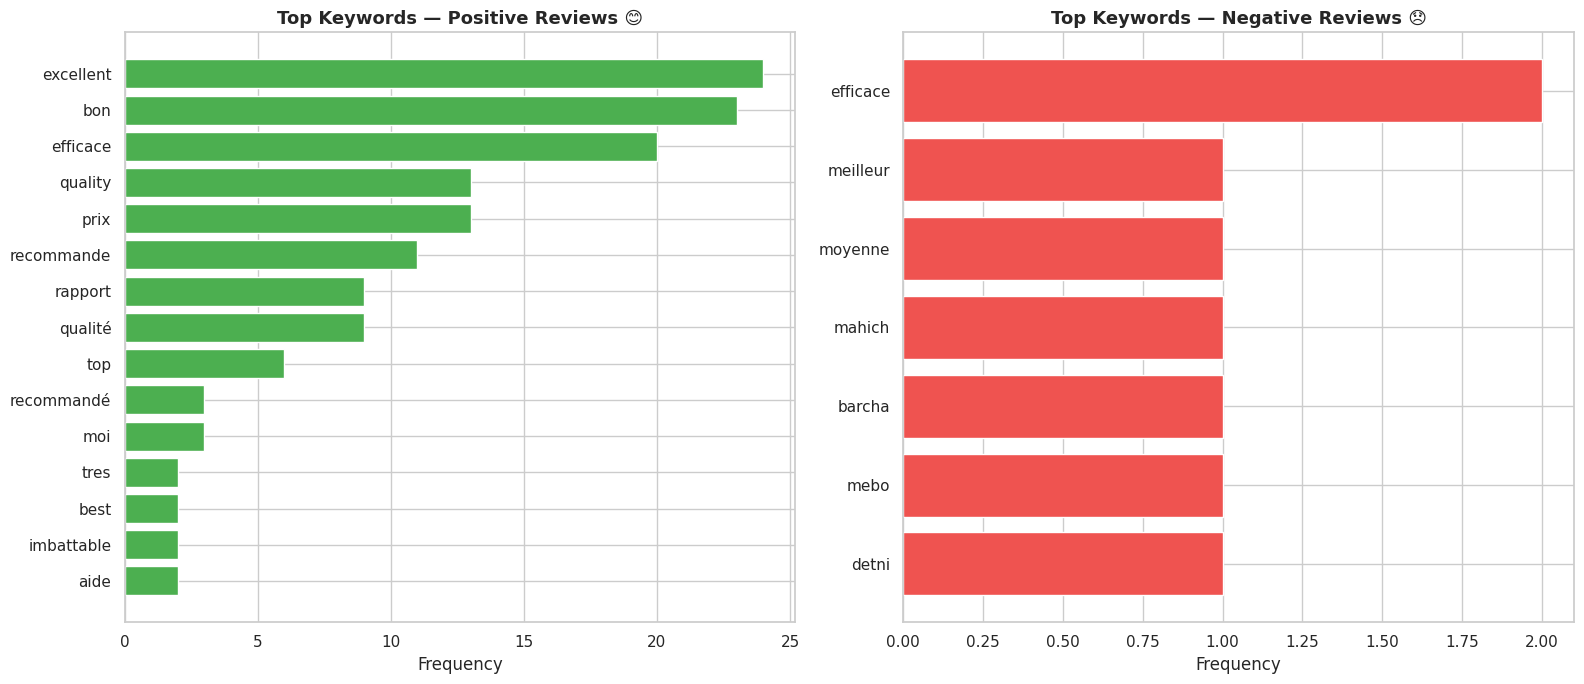

In [ ]:
STOPWORDS = {'le','la','les','de','du','des','et','en','à','au','aux','un','une','je',
             'vous','que','qui','pour','sur','avec','par','dans','est','se','ne','pas',
             'plus','ce','son','sa','nous','il','ils','elle','elles','mon','votre','leur',
             'leurs','me','on','si','ou','mais','donc','car','ni','or','the','of','and',
             'to','is','in','this','it','good','very','product','nice','bien','très',
             'produit','product','nan','none','je','j','ai','l','m','s','c','qu','n'}

def get_tokens(texts):
    tokens = []
    for t in texts:
        words = re.findall(r"[a-zA-ZÀ-ÿ]{3,}", str(t).lower())
        tokens.extend([w for w in words if w not in STOPWORDS])
    return tokens

pos_text = df_text[df_text['sentiment']=='Positive']['commentaire']
neg_text = df_text[df_text['sentiment']=='Negative']['commentaire']
neu_text = df_text[df_text['sentiment']=='Neutral']['commentaire']

pos_freq = Counter(get_tokens(pos_text)).most_common(15)
neg_freq = Counter(get_tokens(neg_text)).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

if pos_freq:
    pw, pv = zip(*pos_freq)
    axes[0].barh(list(reversed(pw)), list(reversed(pv)), color='#4CAF50')
    axes[0].set_title('Top Keywords — Positive Reviews 😊', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Frequency')

if neg_freq:
    nw, nv = zip(*neg_freq)
    axes[1].barh(list(reversed(nw)), list(reversed(nv)), color='#EF5350')
    axes[1].set_title('Top Keywords — Negative Reviews 😞', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Frequency')
else:
    axes[1].text(0.5, 0.5, 'Not enough negative reviews', ha='center', va='center', fontsize=12)
    axes[1].set_title('Top Keywords — Negative Reviews 😞', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

👉 Most reviews are positive, with very few negative comments.
Customer comments are generally very short (≈20 characters).
Neutral reviews tend to be slightly longer than positive or negative ones.

## 👥 BO4.8 — Reviewer Profiles (Audience Segmentation Signals)

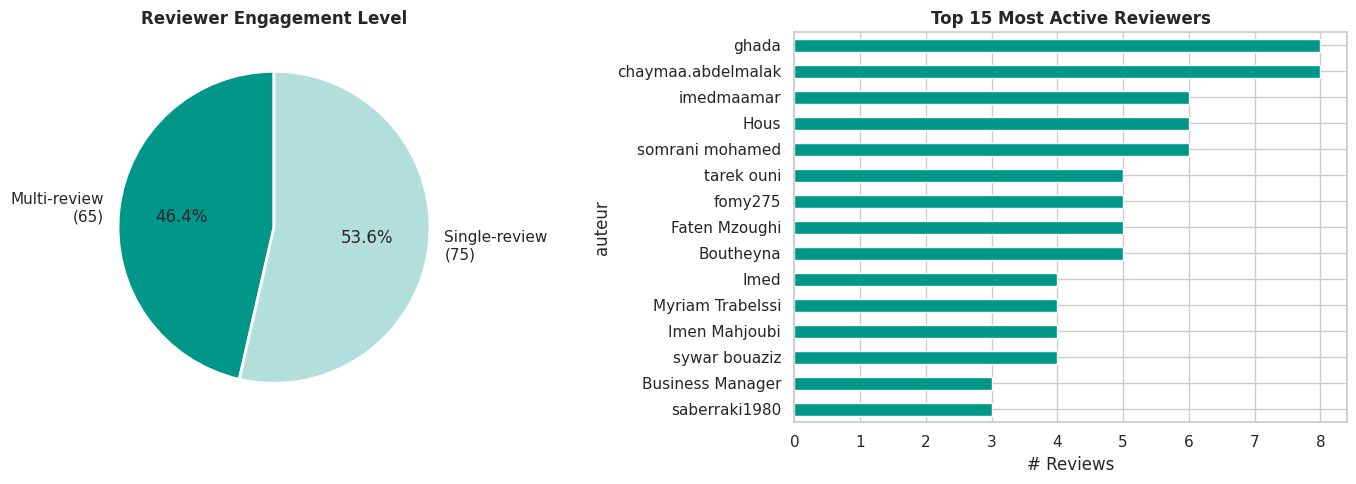


👥 Audience Profile Stats:
  Total unique reviewers   : 140
  Multi-review customers   : 65 (46.4%)


In [ ]:
# ===============================
# Reviewer Engagement Analysis
# ===============================

# Count reviews per reviewer
reviewer_counts = df_reviews['auteur'].value_counts()

# Reviewers with multiple reviews (engaged audience)
multi_reviewers = reviewer_counts[reviewer_counts > 1]

# ===============================
# Create figure
# ===============================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1️⃣ Reviewer engagement
sizes_eng = [
    len(multi_reviewers),
    len(reviewer_counts) - len(multi_reviewers)
]

axes[0].pie(
    sizes_eng,
    labels=[
        f'Multi-review\n({len(multi_reviewers)})',
        f'Single-review\n({len(reviewer_counts) - len(multi_reviewers)})'
    ],
    autopct='%1.1f%%',
    colors=[TEAL, '#B2DFDB'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Reviewer Engagement Level', fontweight='bold')

# 2️⃣ Top reviewers
top_reviewers = reviewer_counts.head(15)

top_reviewers.sort_values().plot(
    kind='barh',
    ax=axes[1],
    color=TEAL
)

axes[1].set_title('Top 15 Most Active Reviewers', fontweight='bold')
axes[1].set_xlabel('# Reviews')

plt.tight_layout()
plt.show()

# ===============================
# Stats Summary
# ===============================
print('\n👥 Audience Profile Stats:')
print(f'  Total unique reviewers   : {len(reviewer_counts)}')
print(f'  Multi-review customers   : {len(multi_reviewers)} '
      f'({len(multi_reviewers)/len(reviewer_counts)*100:.1f}%)')

👉 Most reviewers leave only one review (≈54%), while 46% are repeat contributors, showing a moderate loyalty level.
Top reviewers contribute up to 8 reviews, indicating a small but valuable group of highly engaged users.

## 🧩 BO4.9 — Product Segmentation Signals

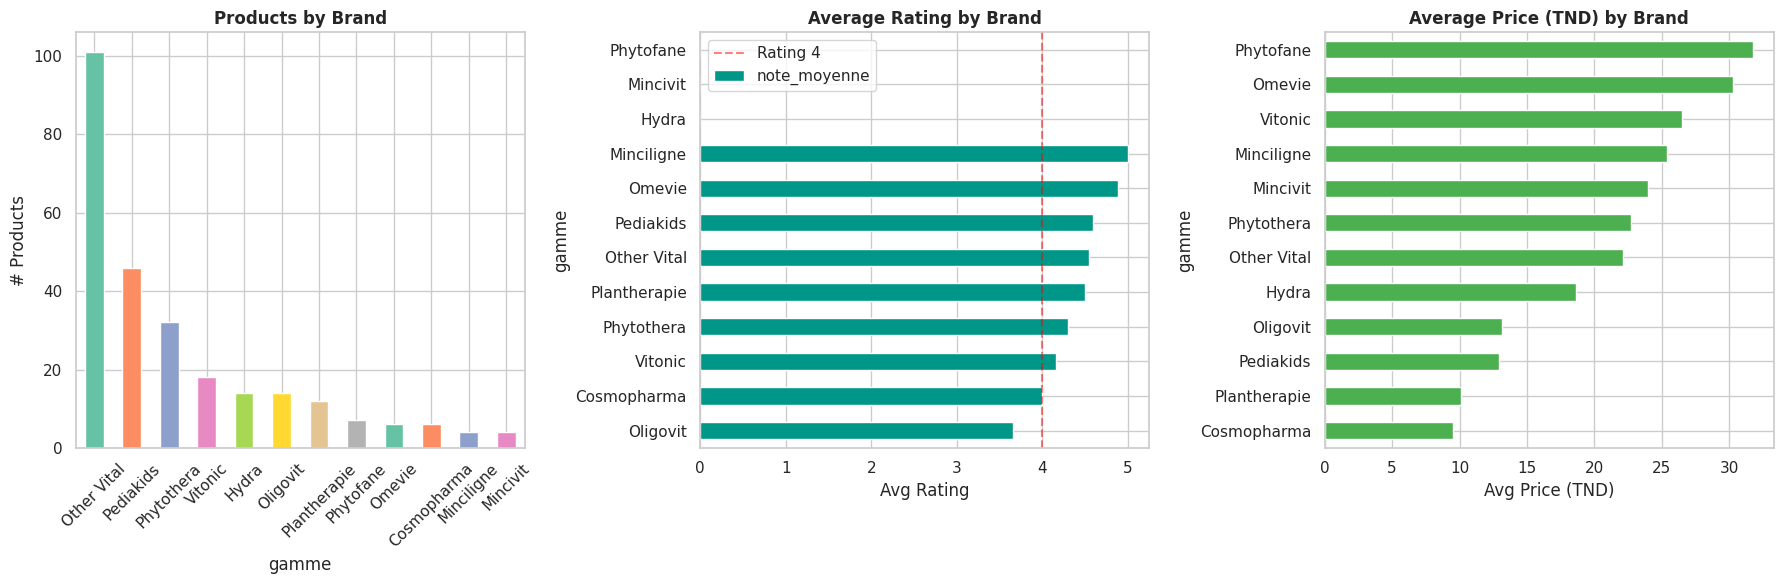


Top brands:
gamme
Other Vital    101
Pediakids       46
Phytothera      32
Vitonic         18
Hydra           14
Name: count, dtype: int64

Most expensive brands:
gamme
Phytofane     31.735286
Omevie        30.300000
Vitonic       26.469500
Minciligne    25.417750
Mincivit      23.987500
Name: prix, dtype: float64

Highest rated brands:
gamme
Minciligne      5.00000
Omevie          4.88000
Pediakids       4.59000
Other Vital     4.54875
Plantherapie    4.50000
Name: note_moyenne, dtype: float64


In [ ]:
# ===============================
# Clean & Extract Brand (Gamme)
# ===============================

import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns

# Function to normalize text (remove accents, lowercase)
def normalize_text(text):
    text = str(text).lower()
    text = unicodedata.normalize('NFD', text)
    text = ''.join(c for c in text if unicodedata.category(c) != 'Mn')
    return text

# Normalize product names
df_products['name_clean'] = df_products['name'].apply(normalize_text)

# Brand detection dictionary
brand_keywords = {
    'vitonic': 'Vitonic',
    'pediakids': 'Pediakids',
    'oligovit': 'Oligovit',
    'omevie': 'Omevie',
    'phytothera': 'Phytothera',
    'phytofane': 'Phytofane',
    'mincivit': 'Mincivit',
    'minciligne': 'Minciligne',
    'bactol': 'Bactol',
    'cosmopharma': 'Cosmopharma',
    'hydra': 'Hydra',
    'plantherapie': 'Plantherapie'
}

# Extract brand from product name
def extract_gamme(name):
    for key, value in brand_keywords.items():
        if key in name:
            return value
    return 'Other Vital'

df_products['gamme'] = df_products['name_clean'].apply(extract_gamme)

# ===============================
# Ensure numeric columns
# ===============================
df_products['note_moyenne'] = pd.to_numeric(df_products['note_moyenne'], errors='coerce')
df_products['prix'] = pd.to_numeric(df_products['prix'], errors='coerce')

# ===============================
# Create plots
# ===============================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1️⃣ Products by gamme
gamme_counts = df_products['gamme'].value_counts()

gamme_counts.plot(
    kind='bar',
    ax=axes[0],
    color=sns.color_palette('Set2', len(gamme_counts))
)

axes[0].set_title('Products by Brand', fontweight='bold')
axes[0].set_ylabel('# Products')
axes[0].tick_params(axis='x', rotation=45)

# 2️⃣ Average rating by gamme
gamme_rating = (
    df_products.groupby('gamme')['note_moyenne']
    .mean()
    .sort_values()
)

gamme_rating.plot(kind='barh', ax=axes[1], color=TEAL)

axes[1].set_title('Average Rating by Brand', fontweight='bold')
axes[1].set_xlabel('Avg Rating')
axes[1].axvline(4, color='red', linestyle='--', alpha=0.5, label='Rating 4')
axes[1].legend()

# 3️⃣ Average price by gamme
gamme_price = (
    df_products.groupby('gamme')['prix']
    .mean()
    .sort_values()
)

gamme_price.plot(kind='barh', ax=axes[2], color=GREEN)

axes[2].set_title('Average Price (TND) by Brand', fontweight='bold')
axes[2].set_xlabel('Avg Price (TND)')

plt.tight_layout()
plt.show()

# ===============================
# Quick summary
# ===============================
print("\nTop brands:")
print(gamme_counts.head())

print("\nMost expensive brands:")
print(gamme_price.sort_values(ascending=False).head())

print("\nHighest rated brands:")
print(gamme_rating.sort_values(ascending=False).head())

👉 Other Vital dominates in product count, followed by Pédiakids and Phytothera, showing strong portfolio coverage.
Most brands have high ratings (>4⭐), with Minciligne and Omevie leading, while Phytofané and Omevie are the most premium-priced.

## 🤖 BO4.10 — NLP Readiness Assessment

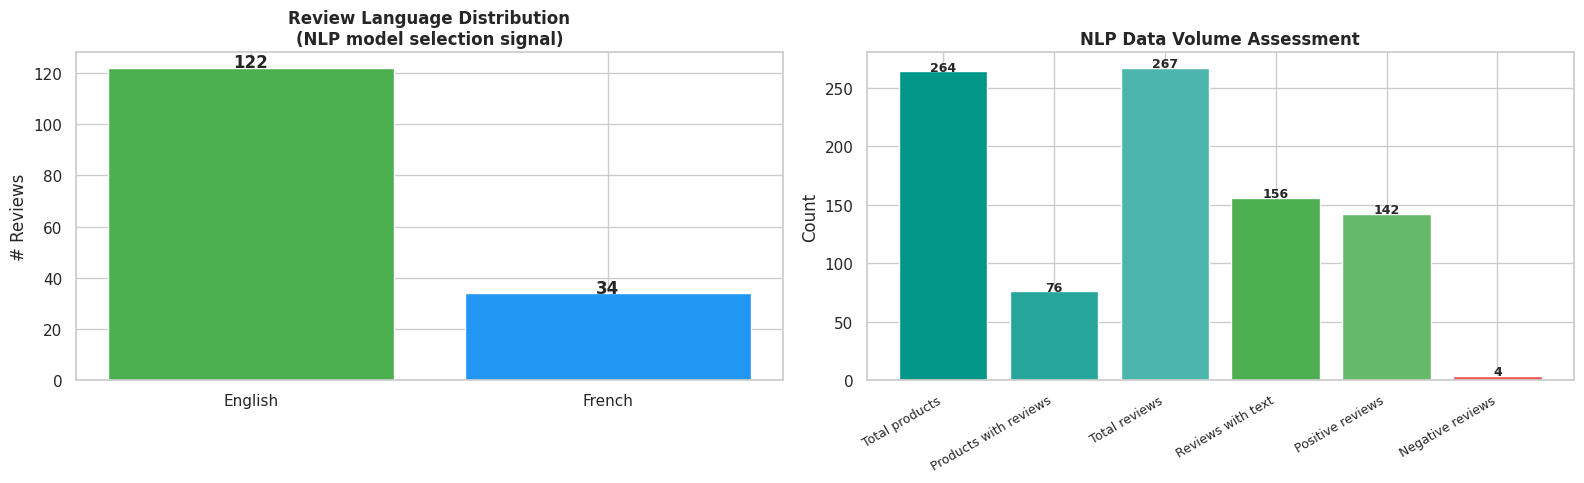


🌍 Language breakdown:
  English   : 122 (78.2%)
  French    :  34 (21.8%)


In [ ]:
# Language detection (simple heuristic)
def detect_lang(text):
    text = str(text).lower()
    fr_words = ['le', 'la', 'les', 'de', 'du', 'très', 'bon', 'bien', 'pas', 'pour', 'avec', 'produit']
    ar_chars = re.findall(r'[\u0600-\u06FF]', text)
    fr_matches = sum(1 for w in fr_words if w in text.split())
    if ar_chars:
        return 'Arabic'
    elif fr_matches >= 2:
        return 'French'
    elif re.search(r'[a-zA-Z]{3,}', text):
        return 'English'
    else:
        return 'Other'

df_text['language'] = df_text['commentaire'].apply(detect_lang)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Language distribution
lang_counts = df_text['language'].value_counts()
lang_colors = {'French': '#2196F3', 'English': '#4CAF50', 'Arabic': '#FF9800', 'Other': '#9E9E9E'}
bar_colors_lang = [lang_colors.get(l, TEAL) for l in lang_counts.index]
bars = axes[0].bar(lang_counts.index, lang_counts.values, color=bar_colors_lang)
axes[0].set_title('Review Language Distribution\n(NLP model selection signal)', fontweight='bold')
axes[0].set_ylabel('# Reviews')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(int(bar.get_height())), ha='center', fontweight='bold')

# NLP data volume assessment
categories_nlp = [
    'Total products', 'Products with reviews', 'Total reviews',
    'Reviews with text', 'Positive reviews', 'Negative reviews'
]
values_nlp = [
    len(df_products),
    (df_products['nb_avis_actual'] > 0).sum(),
    len(df_reviews),
    len(df_text),
    (df_text['sentiment']=='Positive').sum(),
    (df_text['sentiment']=='Negative').sum()
]
colors_nlp = [TEAL, '#26A69A', '#4DB6AC', GREEN, '#66BB6A', '#EF5350']
bars2 = axes[1].bar(range(len(categories_nlp)), values_nlp, color=colors_nlp)
axes[1].set_xticks(range(len(categories_nlp)))
axes[1].set_xticklabels(categories_nlp, rotation=30, ha='right', fontsize=9)
axes[1].set_title('NLP Data Volume Assessment', fontweight='bold')
axes[1].set_ylabel('Count')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(int(bar.get_height())), ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print('\n🌍 Language breakdown:')
for lang, cnt in lang_counts.items():
    print(f'  {lang:10s}: {cnt:3d} ({cnt/len(df_text)*100:.1f}%)')

## 📋 BO4.11 — Data Quality Summary Report

In [ ]:
line = "═" * 70

print(line)
print("📊 BO4 — DATA ACQUISITION & UNDERSTANDING SUMMARY")
print("🎯 Audience Segmentation for Compliant Targeted Marketing")
print(line)

print("\n📁 DATASET OVERVIEW")
print(f"   🧴 Total products           : {len(df_products)}")
print(f"   🗂 Products with reviews    : {(df_products['nb_avis_actual']>0).sum()} "
      f"({(df_products['nb_avis_actual']>0).mean()*100:.1f}%)")
print(f"   💬 Total reviews            : {len(df_reviews)}")
print(f"   📝 Reviews with text        : {len(df_text)} "
      f"({len(df_text)/len(df_reviews)*100:.1f}%)")
print(f"   👥 Unique reviewers         : {df_reviews['auteur'].nunique()}")

print("\n⭐ QUALITY METRICS")
print(f"   ⭐ Avg rating (products)    : {df_products['note_moyenne'].mean():.2f}/5")
print(f"   ⭐ Avg rating (reviews)     : {df_reviews['note'].mean():.2f}/5")
print(f"   ✍️ Avg comment length      : {df_text['len_comment'].mean():.0f} chars")
print(f"   🏷 Gammes detected          : {df_products['gamme'].nunique()}")

print("\n📊 SENTIMENT DISTRIBUTION (text reviews)")
for sent in ['Positive', 'Neutral', 'Negative']:
    cnt = (df_text['sentiment'] == sent).sum()
    print(f"   {sent:10s}: {cnt:3d} ({cnt/len(df_text)*100:.1f}%)")

print("\n🔎 KEY INSIGHTS")
print("   ✔ Strong positive sentiment → strong brand perception")
print("   ✔ Multilingual reviews → multilingual NLP required")
print("   ✔ Limited labeled data → semi-supervised / LLM approach recommended")
print("   ✔ Uneven review volume → prioritize low-review gammes")

print(line)

══════════════════════════════════════════════════════════════════════
📊 BO4 — DATA ACQUISITION & UNDERSTANDING SUMMARY
🎯 Audience Segmentation for Compliant Targeted Marketing
══════════════════════════════════════════════════════════════════════

📁 DATASET OVERVIEW
   🧴 Total products           : 264
   🗂 Products with reviews    : 76 (28.8%)
   💬 Total reviews            : 267
   📝 Reviews with text        : 156 (58.4%)
   👥 Unique reviewers         : 140

⭐ QUALITY METRICS
   ⭐ Avg rating (products)    : 4.41/5
   ⭐ Avg rating (reviews)     : 4.41/5
   ✍️ Avg comment length      : 20 chars
   🏷 Gammes detected          : 12

📊 SENTIMENT DISTRIBUTION (text reviews)
   Positive  : 142 (91.0%)
   Neutral   :  10 (6.4%)
   Negative  :   4 (2.6%)

🔎 KEY INSIGHTS
   ✔ Strong positive sentiment → strong brand perception
   ✔ Multilingual reviews → multilingual NLP required
   ✔ Limited labeled data → semi-supervised / LLM approach recommended
   ✔ Uneven review volume → prioritize low-rev